# **ANNUAL WEATHER TYPES: SENSIVILITY ANALYSIS**


In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd


warnings.filterwarnings("ignore")

import os.path as op
import numpy as np
from bluemath_tk.core.io import load_model
from utils.codes import amo_format, ao_format, nao_format, plot_index, scand_format, n34_format, olr_format, pdo_format, soi_format, pna_format, sam_format

## Climate Indexes

In [2]:
awt = load_model("outputs/awt_model_oporto.pkl")

In [3]:
pcs = awt.steps.get("pca").pcs.copy()
pcs


<xarray.Dataset> Size: 1kB
Dimensions:      (time: 40, n_component: 3)
Coordinates:
  * time         (time) datetime64[ns] 320B 1979-01-01 1980-01-01 ... 2018-01-01
  * n_component  (n_component) int64 24B 0 1 2
Data variables:
    PCs          (time, n_component) float64 960B 2.793 1.628 ... -1.607 -1.738
    stds         (n_component) float64 24B 2.479 1.792 1.629
    kma_bmus     (time) int32 160B 1 3 1 3 3 1 3 3 1 1 2 ... 2 1 1 3 2 2 2 3 2 2

In [4]:
p_index = "inputs/Index_Data"

In [5]:
list_colors = [
    "indianred",
    "royalblue",
    "orchid",
    "mediumaquamarine",
    "gold",
    "plum",
    "#FF5733",
    "#33FF57",
    "#3366FF",
    "#FF33BB",
    "#FFD700",
    "#4B0082",
    "#00FFD1",
    "#FF6347",
    "#8A2BE2",
    "#FFA500",
]

## AO

In [6]:
ao_p = np.loadtxt(op.join(p_index, "ao.txt"), skiprows=2, usecols=np.arange(0, 13))
ao = ao_format(ao_p, rolling_mean=0, rol_months=1)


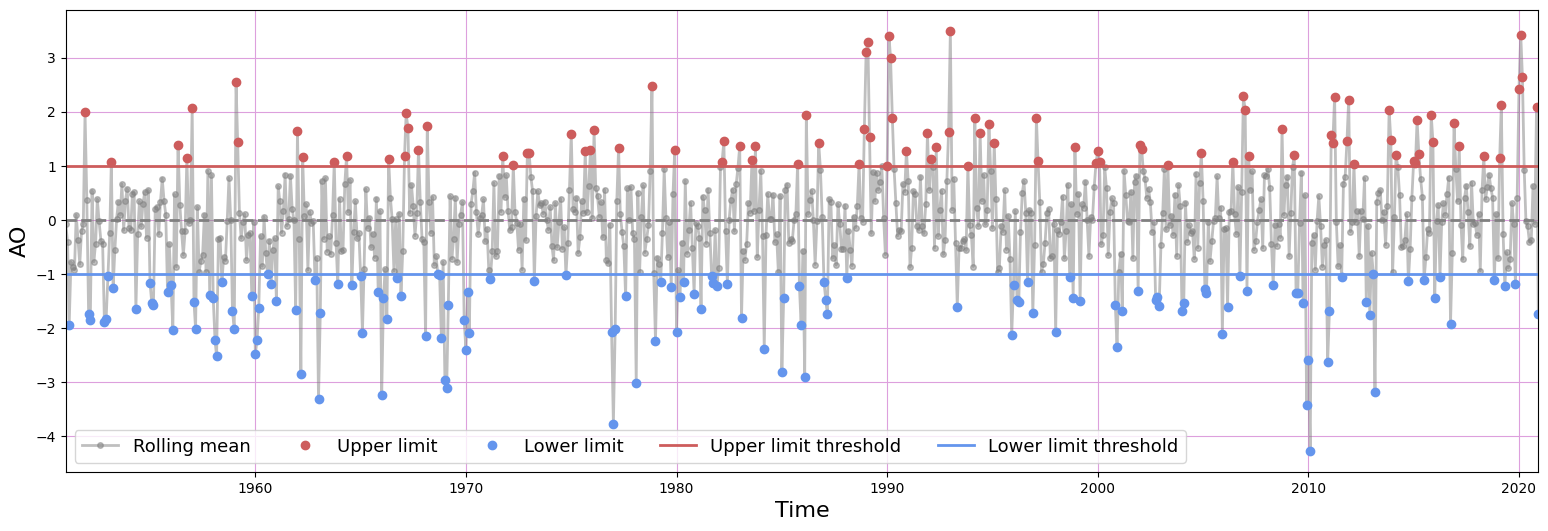

In [7]:
thr1 = 1
thr2 = -1
ao = plot_index(ao, name="AO", l1=thr1, l2=thr2, figsize=[19, 6])

In [8]:
u = np.intersect1d(pcs.time.values, ao.time.values)
pcs_ao = pcs.sel(time=u)
pcs_ao["ao"] = (("time"), ao.sel(time=u).index.values)
pcs_ao = pcs_ao.rename({"n_component": "n_pcs"})

In [9]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_AO = []
for i in pcs_ao.n_pcs.values:
    CORR_AO.append(
        (np.corrcoef(pcs_ao.PCs.isel(n_pcs=i).values, pcs_ao.ao.values)[0, 1])
    )
CORR_AO = np.array(CORR_AO)

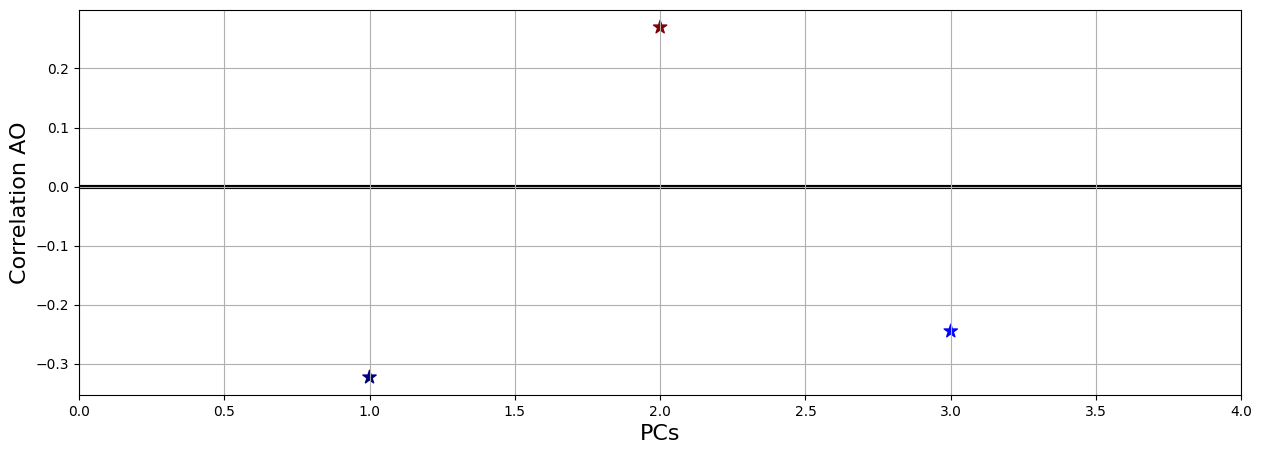

In [10]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_ao.n_pcs.values + 1, CORR_AO, s=100, c=CORR_AO, marker="*", cmap="jet", label=""
)
ax.plot(
    [pcs_ao.n_pcs.values[0], pcs_ao.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_ao.n_pcs.values[0], pcs_ao.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation AO", fontsize=16)
ax.grid()

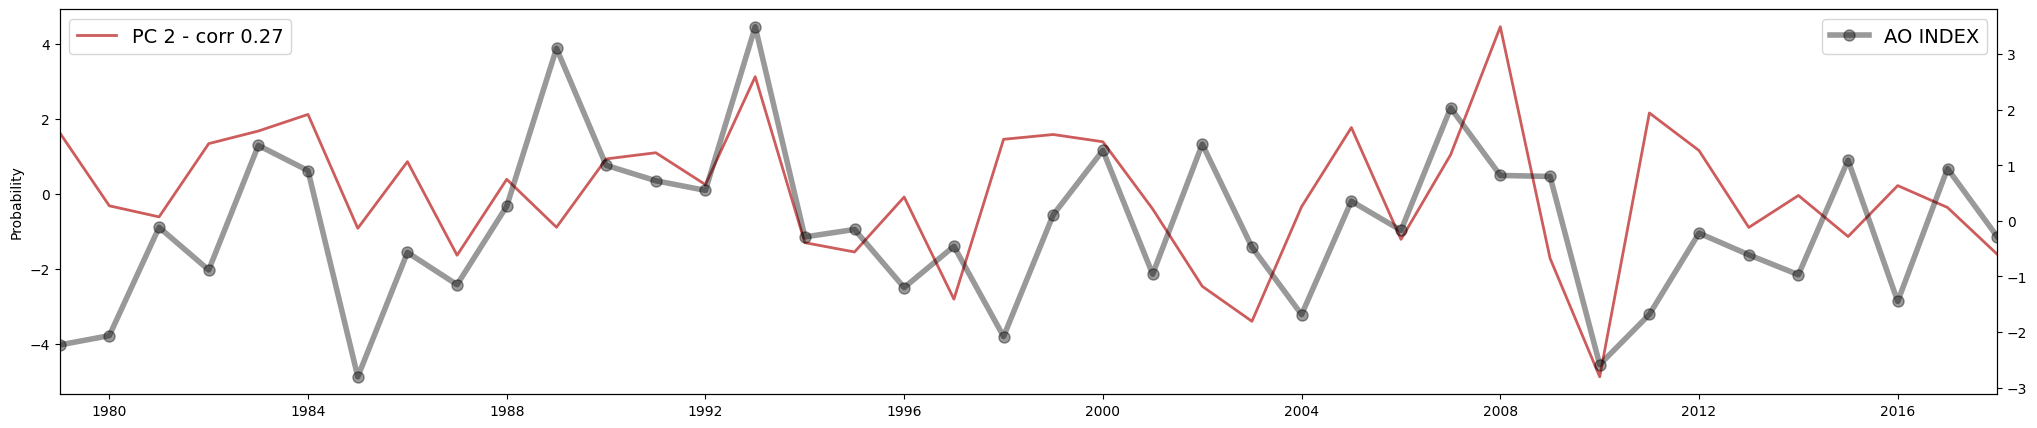

In [11]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_AO > 0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_ao.time.values,
        pcs_ao.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_AO[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_ao.time.values[0], pcs_ao.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_ao.time.values,
    pcs_ao.ao.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="AO INDEX",
)
ax1.legend(fontsize=14, loc=1)

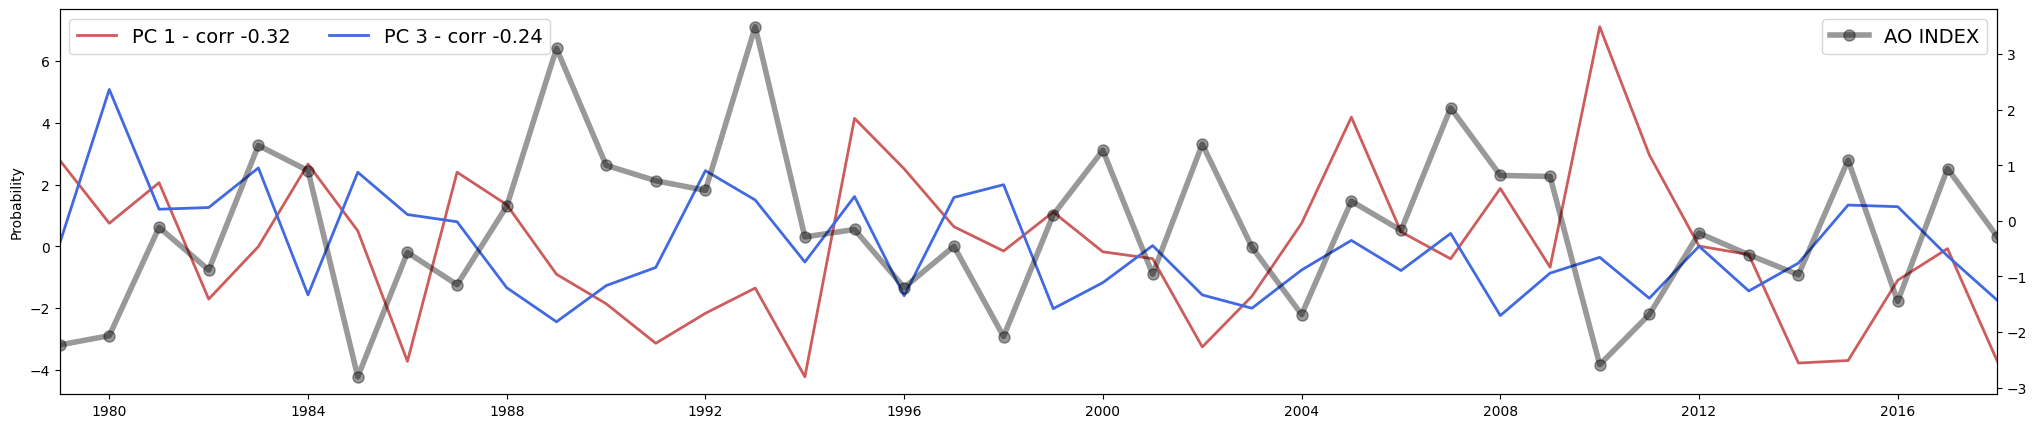

In [12]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_AO < -0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_ao.time.values,
        pcs_ao.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_AO[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_ao.time.values[0], pcs_ao.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_ao.time.values,
    pcs_ao.ao.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="AO INDEX",
)
ax1.legend(fontsize=14, loc=1)

## AMO

In [13]:
amo_p = np.loadtxt(op.join(p_index, "amo.txt"), skiprows=1, usecols=np.arange(0, 13))
amo = amo_format(amo_p, rolling_mean=0, rol_months=1)


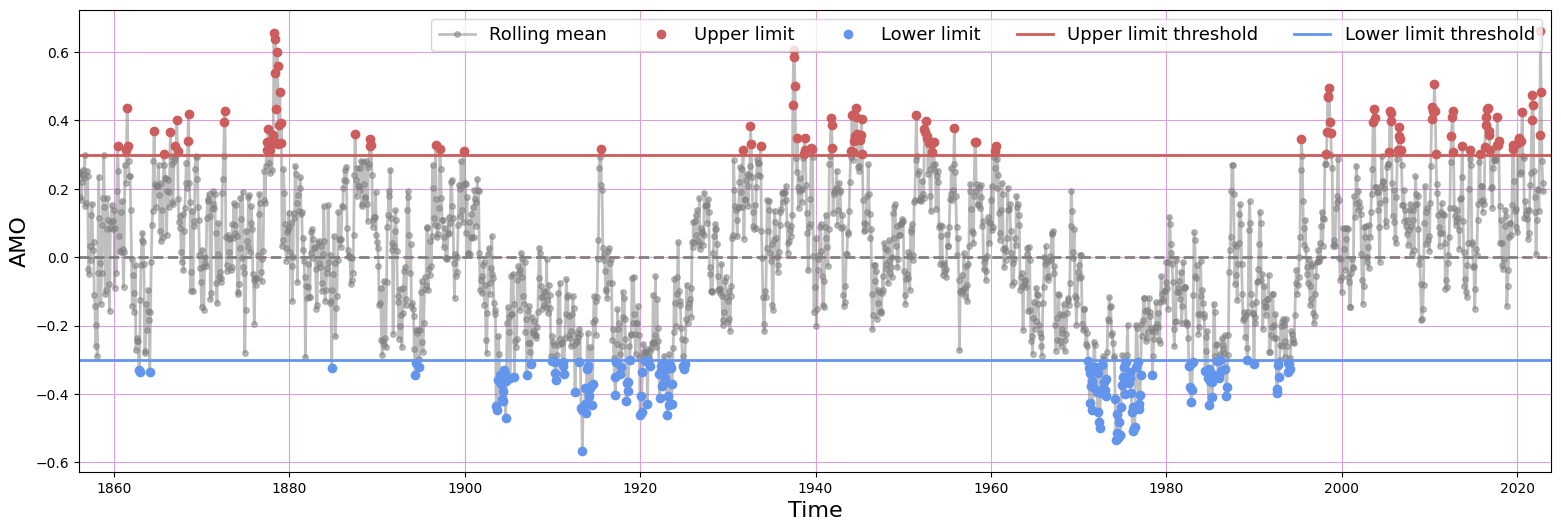

In [14]:
thr1 = 0.3
thr2 = -0.3
amo = plot_index(amo, name="AMO", l1=thr1, l2=thr2, figsize=[19, 6])

In [15]:
u = np.intersect1d(pcs.time.values, amo.time.values)
pcs_amo = pcs.sel(time=u)
pcs_amo["amo"] = (("time"), amo.sel(time=u).index.values)
pcs_amo = pcs_amo.rename({"n_component": "n_pcs"})
pcs_amo = pcs_amo.dropna(dim="time")

In [16]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_AMO = []
for i in pcs_amo.n_pcs.values:
    CORR_AMO.append(
        (np.corrcoef(pcs_amo.PCs.isel(n_pcs=i).values, pcs_amo.amo.values)[0, 1])
    )
CORR_AMO = np.array(CORR_AMO)

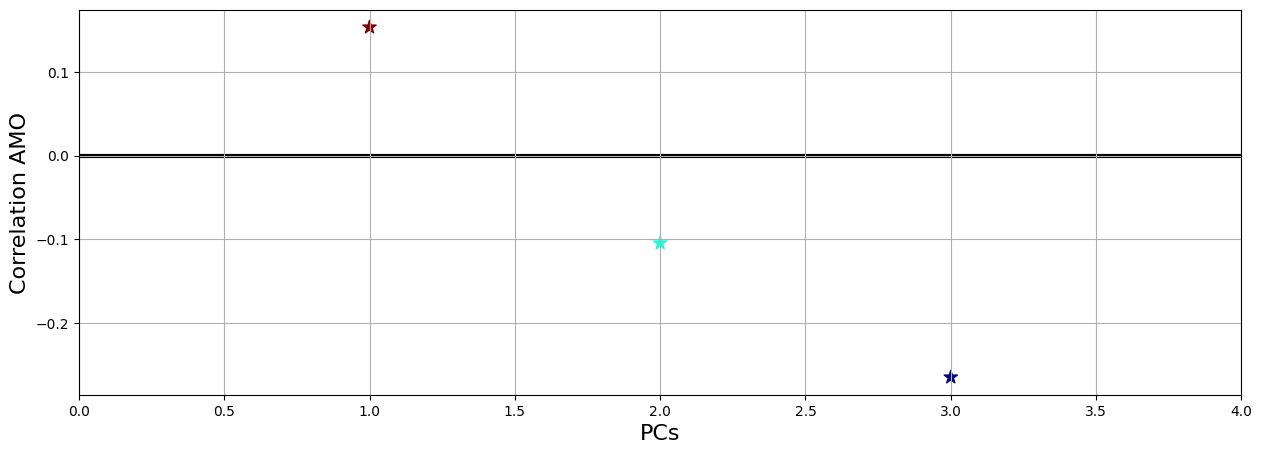

In [17]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_amo.n_pcs.values + 1,
    CORR_AMO,
    s=100,
    c=CORR_AMO,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_amo.n_pcs.values[0], pcs_amo.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_amo.n_pcs.values[0], pcs_amo.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation AMO", fontsize=16)
ax.grid()

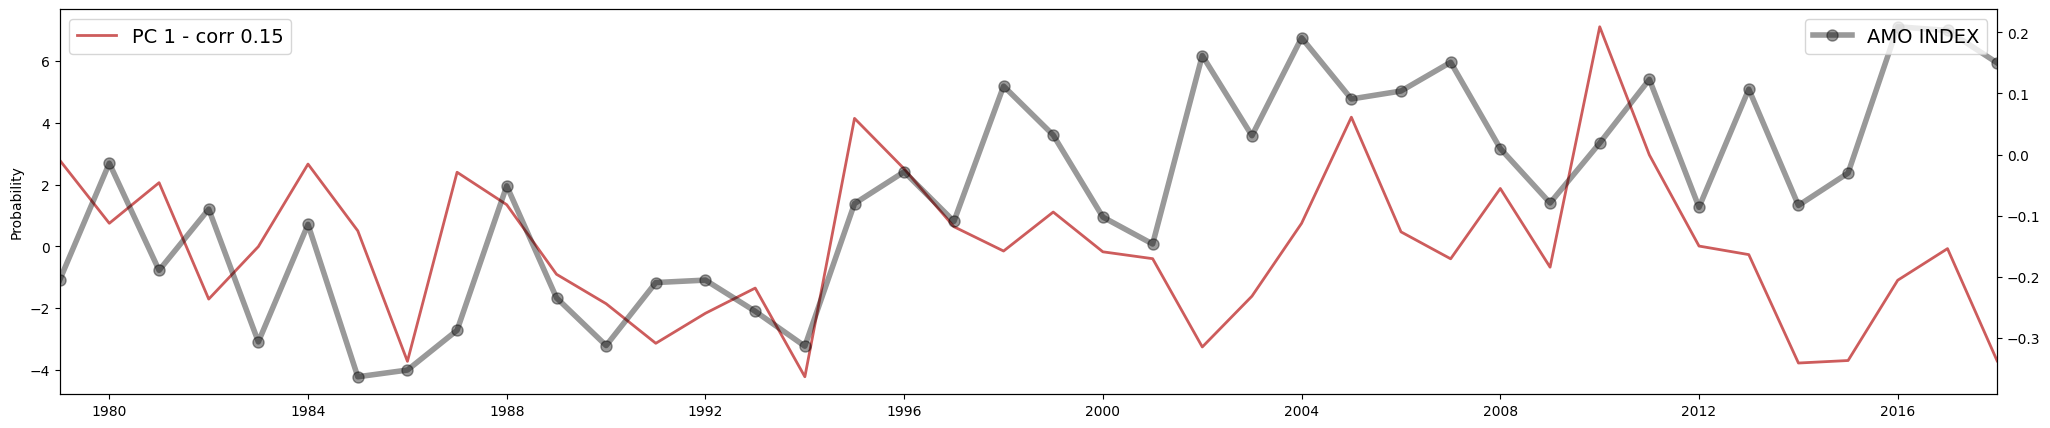

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_AMO > 0.1)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_amo.time.values,
        pcs_amo.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_AMO[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_amo.time.values[0], pcs_amo.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_amo.time.values,
    pcs_amo.amo.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="AMO INDEX",
)
ax1.legend(fontsize=14, loc=1)

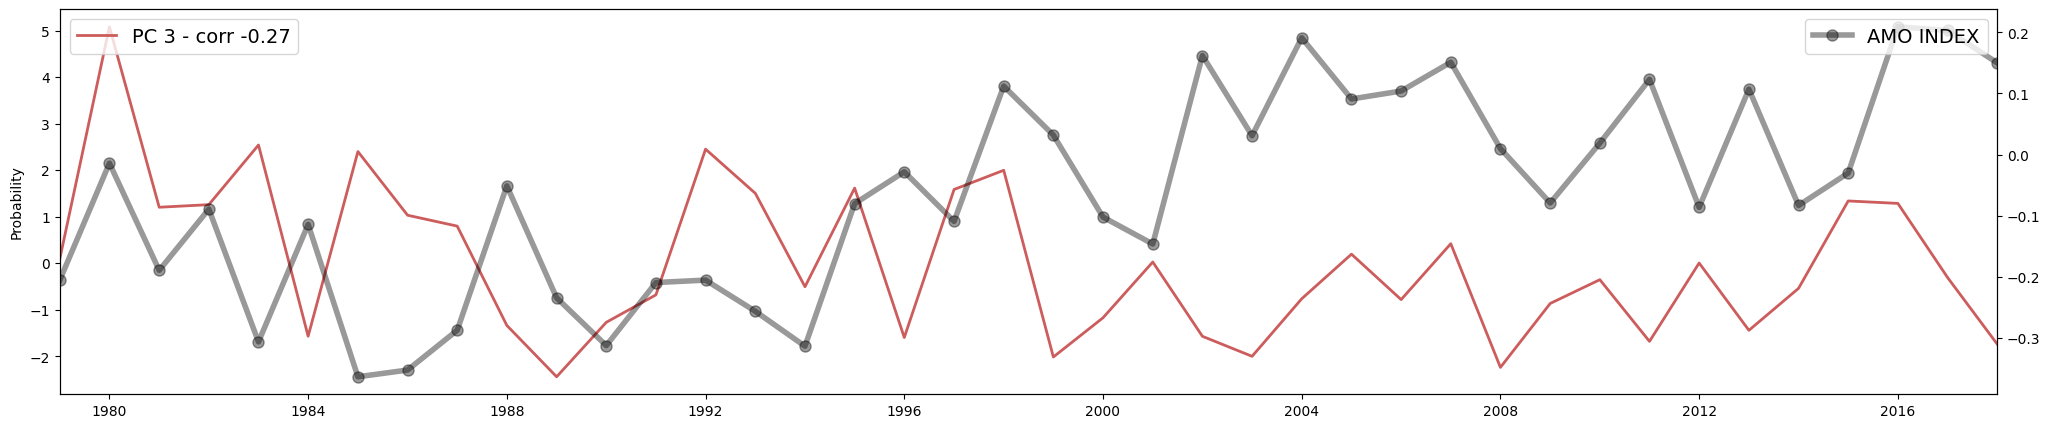

In [19]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_AMO < -0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_amo.time.values,
        pcs_amo.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_AMO[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_amo.time.values[0], pcs_amo.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_amo.time.values,
    pcs_amo.amo.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="AMO INDEX",
)
ax1.legend(fontsize=14, loc=1)

## SCAND

In [20]:
scand_p = np.loadtxt(op.join(p_index, "scand.txt"), skiprows=9)
scand = scand_format(scand_p, rolling_mean=0, rol_months=1)


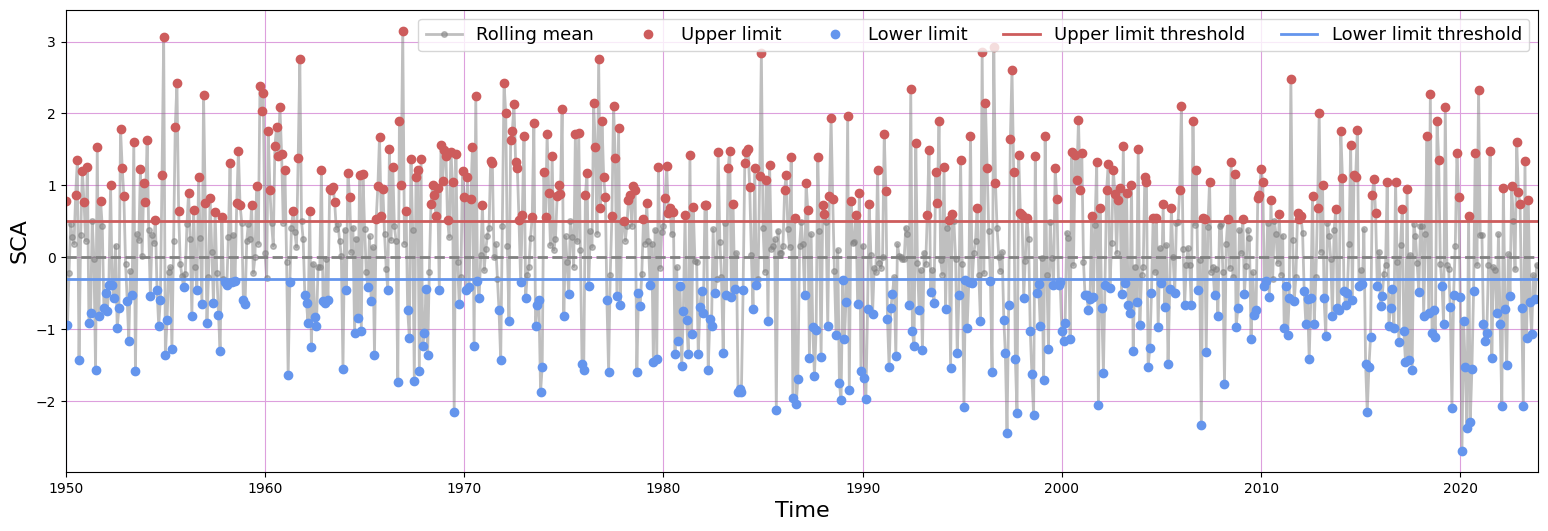

In [21]:
thr1 = 0.5
thr2 = -0.3
scand = plot_index(scand, name="SCA", l1=thr1, l2=thr2, figsize=[19, 6])

In [22]:
u = np.intersect1d(pcs.time.values, scand.time.values)
pcs_scand = pcs.sel(time=u)
pcs_scand["scand"] = (("time"), scand.sel(time=u).index.values)
pcs_scand = pcs_scand.rename({"n_component": "n_pcs"})
pcs_scand = pcs_scand.dropna(dim="time")

In [23]:
#fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_SCA = []
for i in pcs_scand.n_pcs.values:
    CORR_SCA.append(
        (np.corrcoef(pcs_scand.PCs.isel(n_pcs=i).values, pcs_scand.scand.values)[0, 1])
    )
CORR_SCA = np.array(CORR_SCA)

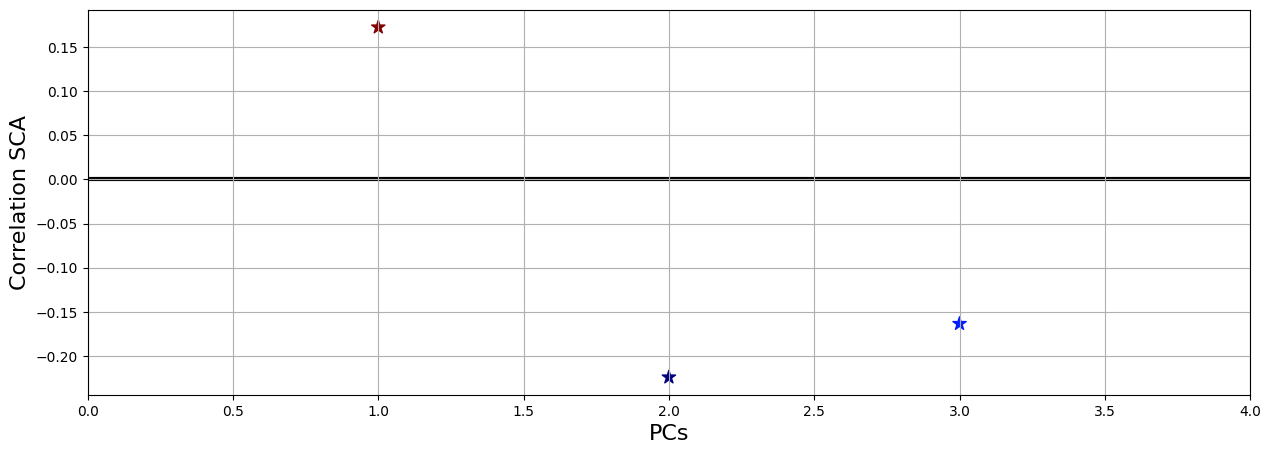

In [24]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_scand.n_pcs.values + 1,
    CORR_SCA,
    s=100,
    c=CORR_SCA,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_scand.n_pcs.values[0], pcs_scand.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_scand.n_pcs.values[0], pcs_scand.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation SCA", fontsize=16)
ax.grid()

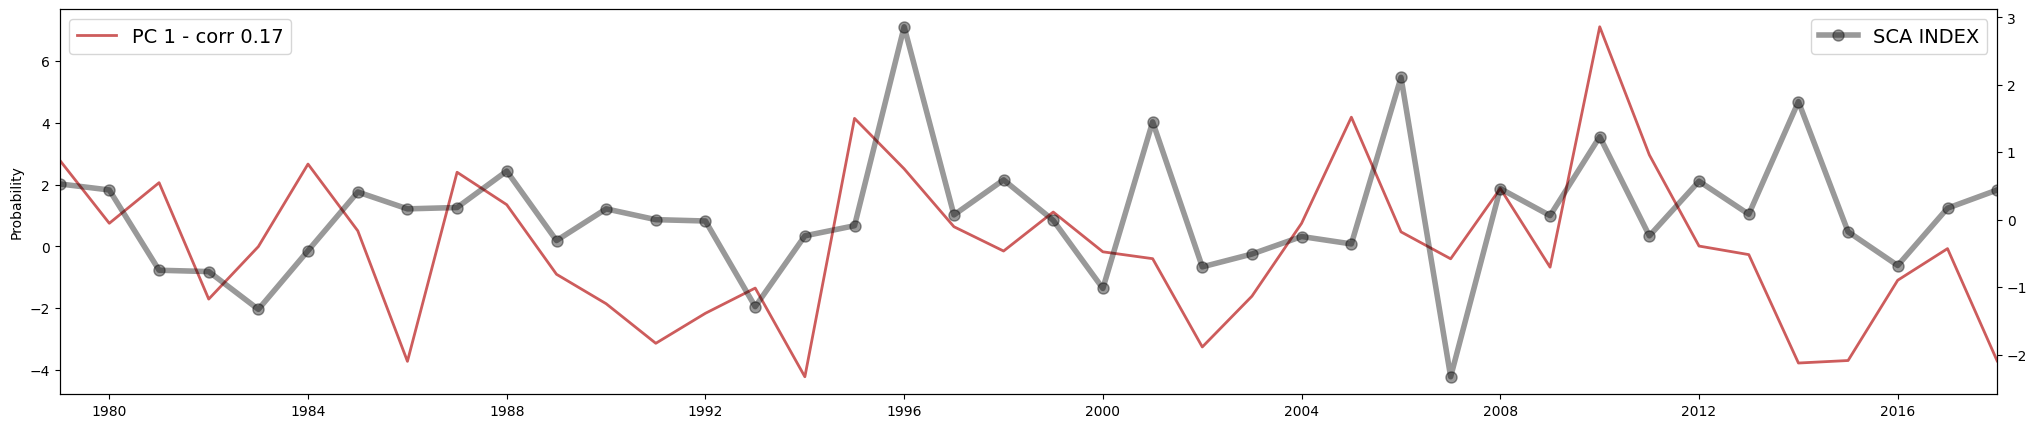

In [25]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_SCA > 0.15)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_scand.time.values,
        pcs_scand.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_SCA[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_scand.time.values[0], pcs_scand.time.values[-1])

ax.legend(fontsize=14, ncol=5, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_scand.time.values,
    pcs_scand.scand.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="SCA INDEX",
)
ax1.legend(fontsize=14, loc=1)

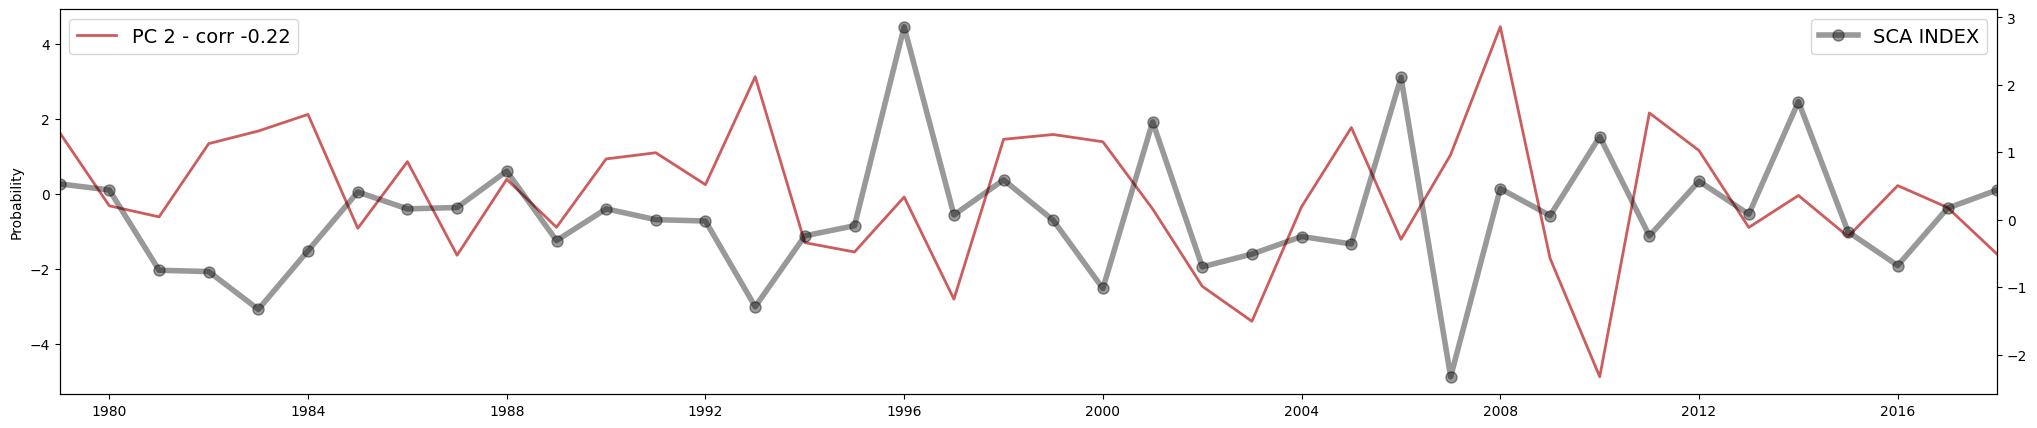

In [26]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_SCA < -0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_scand.time.values,
        pcs_scand.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_SCA[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_scand.time.values[0], pcs_scand.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_scand.time.values,
    pcs_scand.scand.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="SCA INDEX",
)
ax1.legend(fontsize=14, loc=1)

## OLR

In [27]:
olr_p = np.loadtxt(op.join(p_index, "olr.txt"), skiprows=5, usecols=np.arange(0, 13))
olr = olr_format(olr_p, rolling_mean=1, rol_months=1)


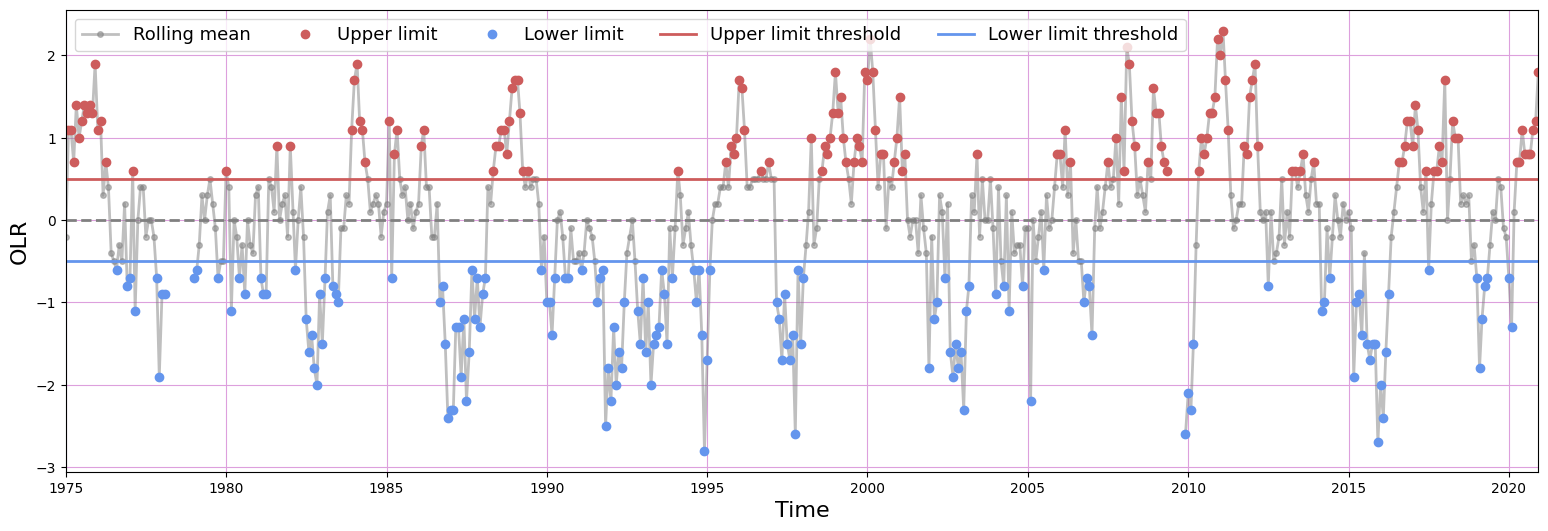

In [28]:
thr1 = 0.5
thr2 = -0.5
olr = plot_index(olr, name="OLR", l1=thr1, l2=thr2, figsize=[19, 6])

In [29]:
olr = olr.dropna(dim="time")

In [30]:
u = np.intersect1d(pcs.time.values, olr.time.values)
pcs_olr = pcs.sel(time=u)
pcs_olr = pcs_olr.rename({"n_component": "n_pcs"})
pcs_olr["olr"] = (("time"), olr.sel(time=u).index.values)

In [31]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_olr = []
for i in pcs_olr.n_pcs.values:
    CORR_olr.append(
        (np.corrcoef(pcs_olr.PCs.isel(n_pcs=i).values, pcs_olr.olr.values)[0, 1])
    )
CORR_olr = np.array(CORR_olr)

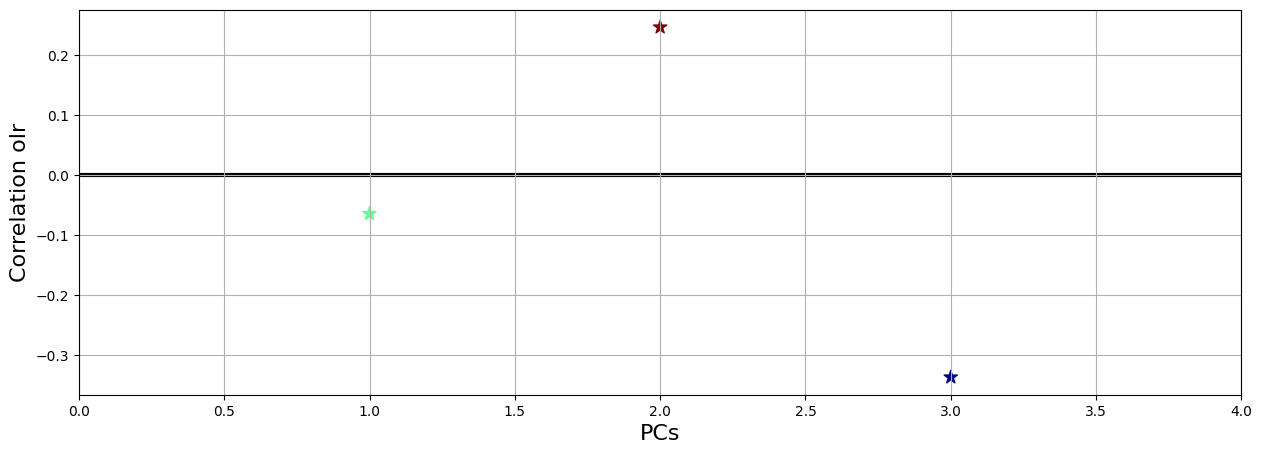

In [32]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_olr.n_pcs.values + 1,
    CORR_olr,
    s=100,
    c=CORR_olr,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation olr", fontsize=16)
ax.grid()

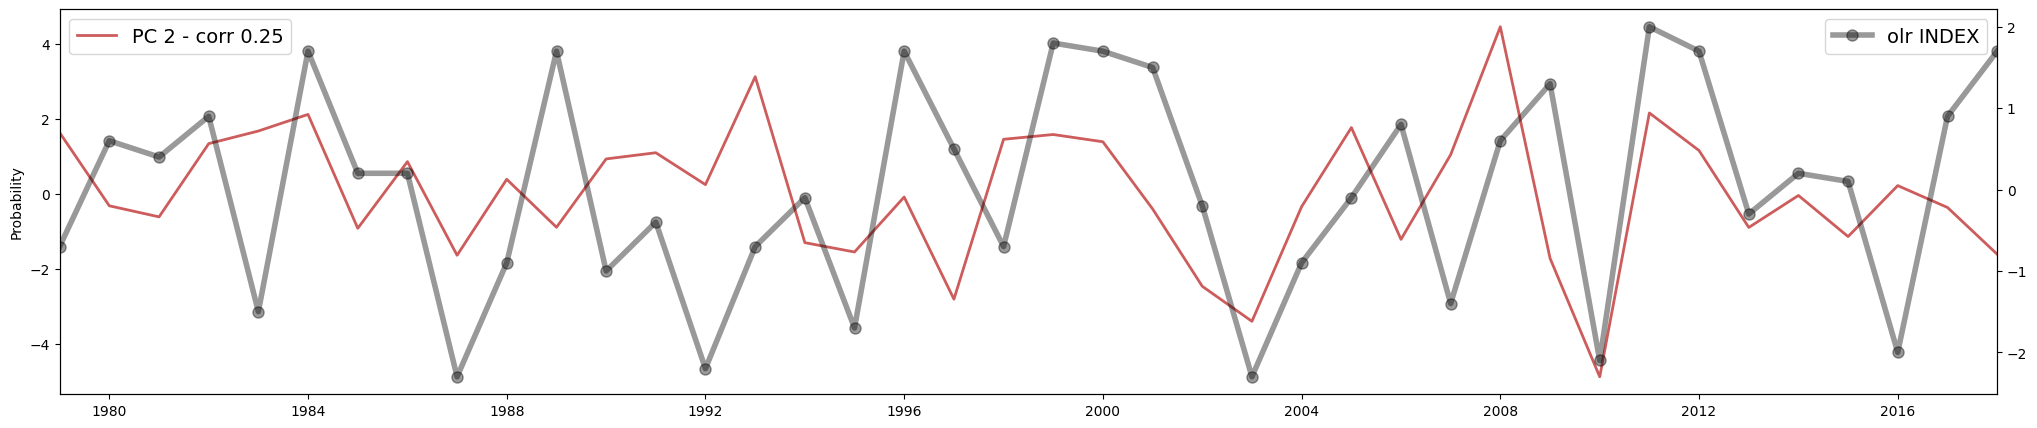

In [33]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_olr > 0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_olr.time.values,
        pcs_olr.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_olr[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_olr.time.values[0], pcs_olr.time.values[-1])

ax.legend(fontsize=14, ncol=5, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_olr.time.values,
    pcs_olr.olr.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="olr INDEX",
)
ax1.legend(fontsize=14, loc=1)

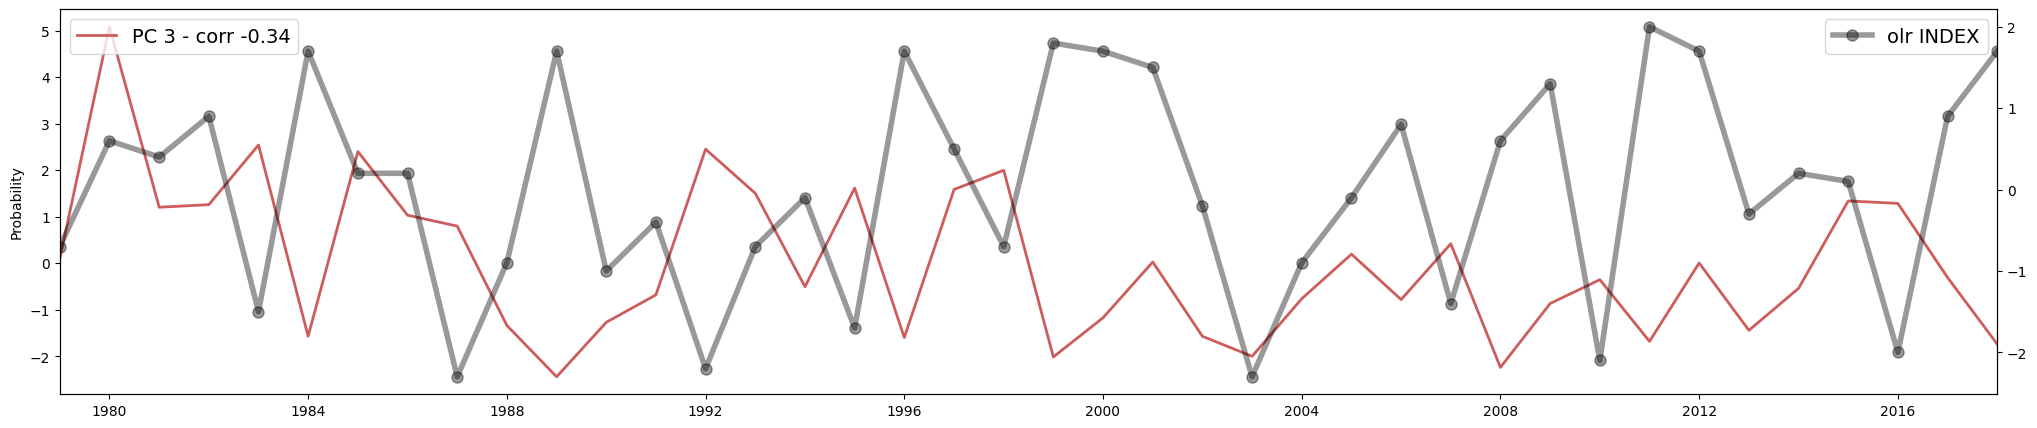

In [34]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_olr < -0.3)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_olr.time.values,
        pcs_olr.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_olr[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_olr.time.values[0], pcs_olr.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_olr.time.values,
    pcs_olr.olr.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="olr INDEX",
)
ax1.legend(fontsize=14, loc=1)

## PDO

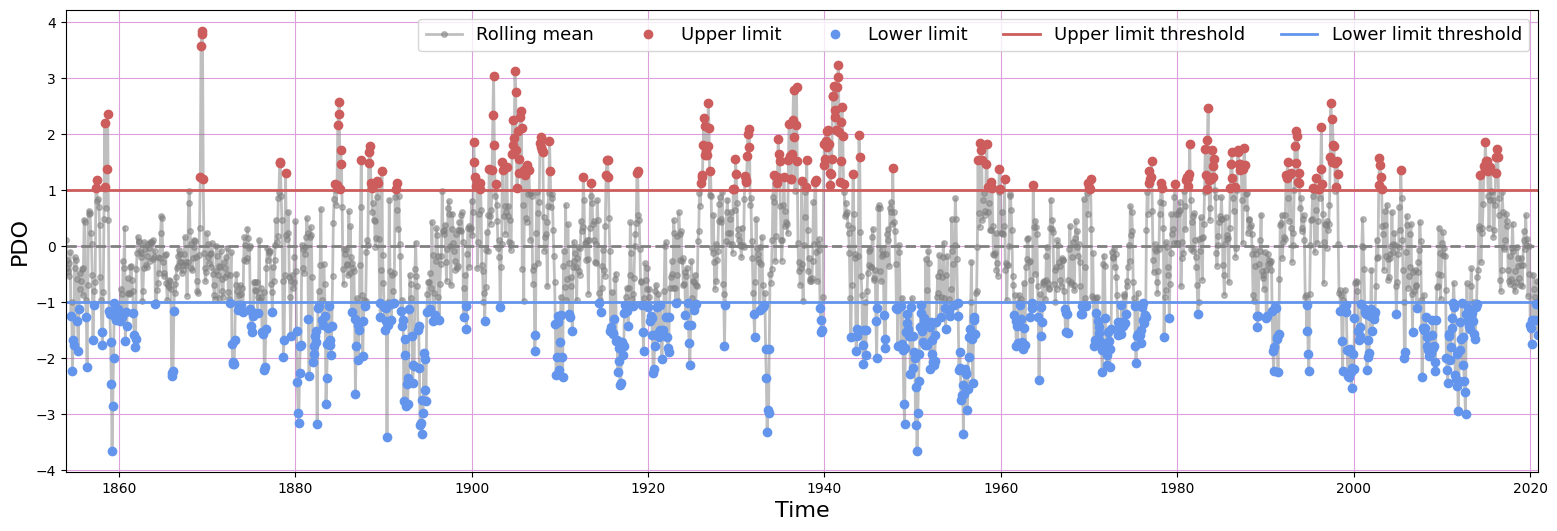

In [35]:
pdo_p = np.loadtxt(op.join(p_index, "pdo.txt"), skiprows=2, usecols=np.arange(0, 13))
pdo = pdo_format(pdo_p, rolling_mean=1, rol_months=1)
thr1 = 1
thr2 = -1
pdo = plot_index(pdo, name="PDO", l1=thr1, l2=thr2, figsize=[19, 6])


In [36]:
pdo = pdo.dropna(dim="time")

In [37]:
u = np.intersect1d(pcs.time.values, pdo.time.values)
pcs_pdo = pcs.sel(time=u)
pcs_pdo = pcs_pdo.rename({"n_component": "n_pcs"})
pcs_pdo["pdo"] = (("time"), pdo.sel(time=u).index.values)

In [38]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_pdo = []
for i in pcs_pdo.n_pcs.values:
    CORR_pdo.append(
        (np.corrcoef(pcs_pdo.PCs.isel(n_pcs=i).values, pcs_pdo.pdo.values)[0, 1])
    )
CORR_pdo = np.array(CORR_pdo)

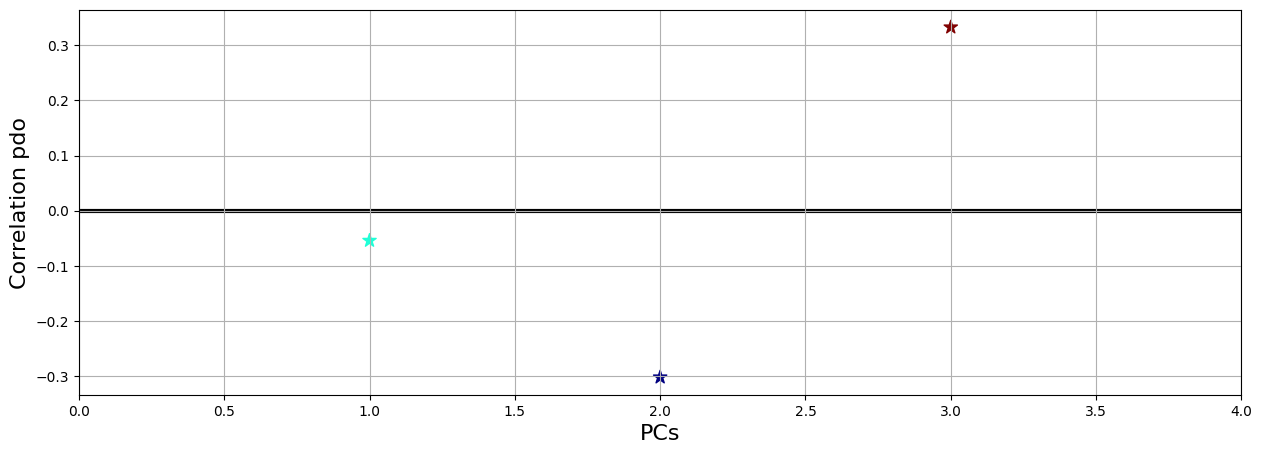

In [39]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_pdo.n_pcs.values + 1,
    CORR_pdo,
    s=100,
    c=CORR_pdo,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_pdo.n_pcs.values[0], pcs_pdo.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_pdo.n_pcs.values[0], pcs_pdo.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation pdo", fontsize=16)
ax.grid()

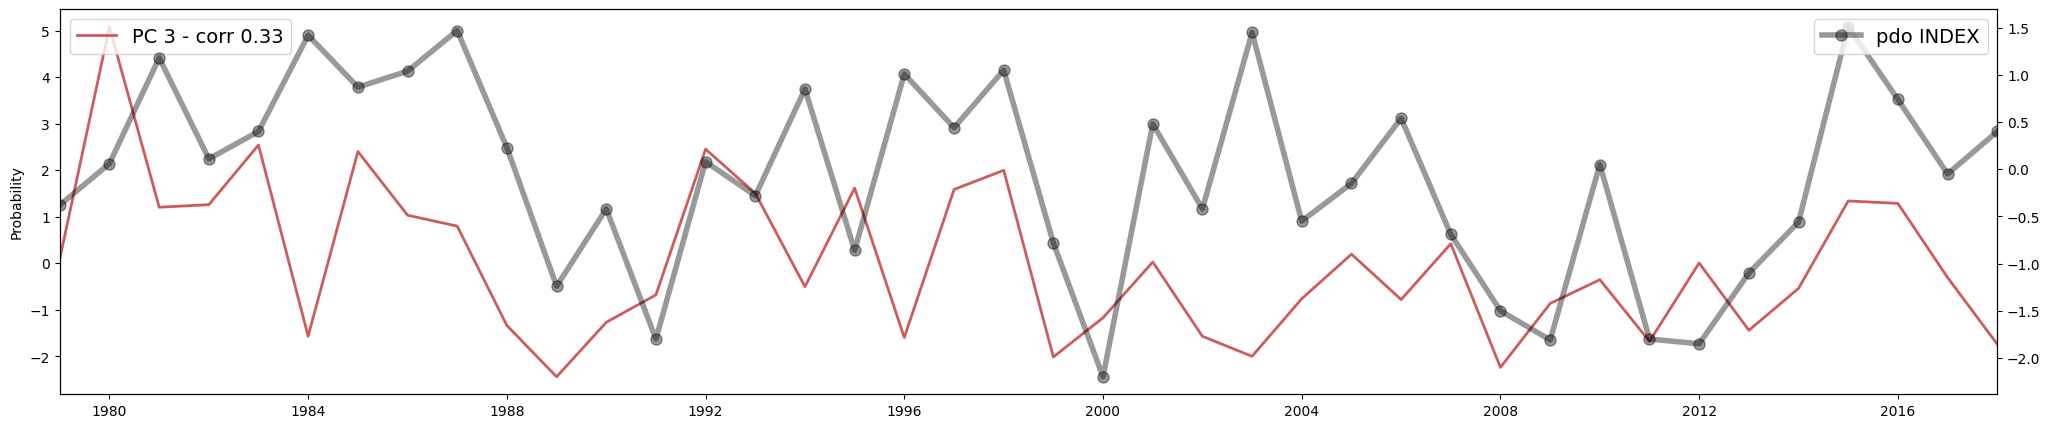

In [40]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_pdo > 0.3)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_pdo.time.values,
        pcs_pdo.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_pdo[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_pdo.time.values[0], pcs_pdo.time.values[-1])

ax.legend(fontsize=14, ncol=5, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_pdo.time.values,
    pcs_pdo.pdo.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="pdo INDEX",
)
ax1.legend(fontsize=14, loc=1)

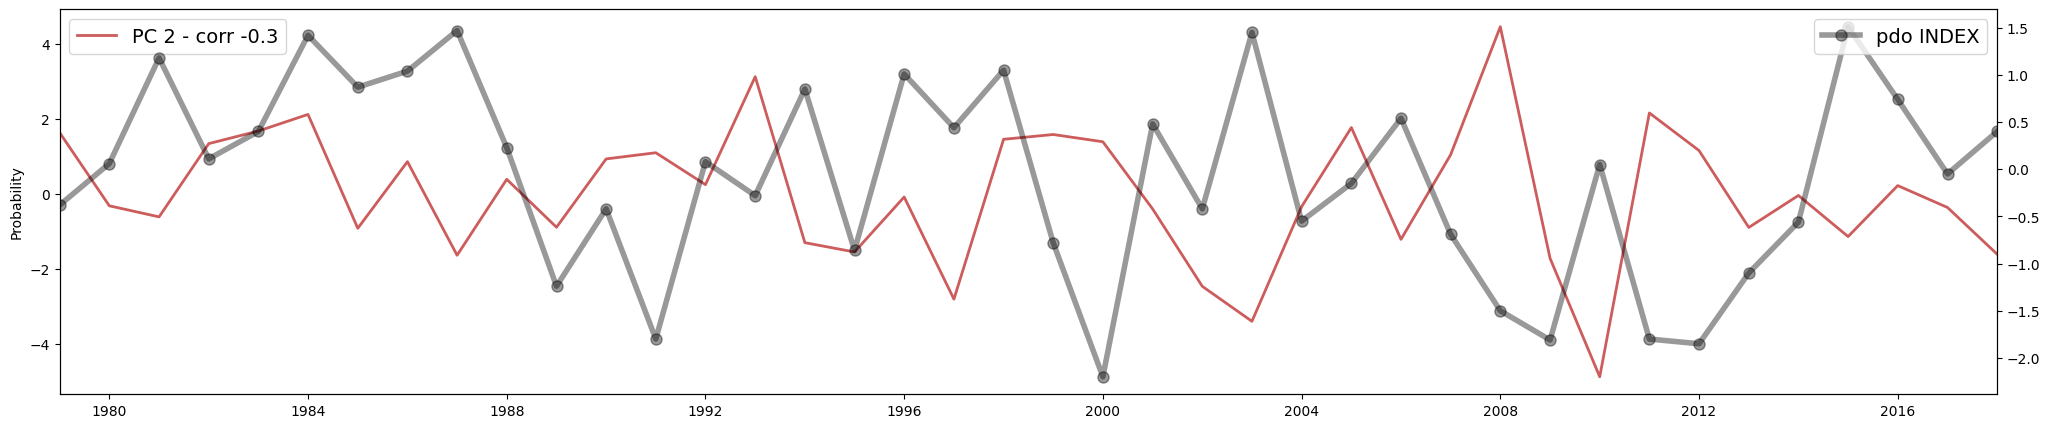

In [41]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_pdo < -0.3)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_pdo.time.values,
        pcs_pdo.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_pdo[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_pdo.time.values[0], pcs_pdo.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_pdo.time.values,
    pcs_pdo.pdo.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="pdo INDEX",
)
ax1.legend(fontsize=14, loc=1)

## SOI

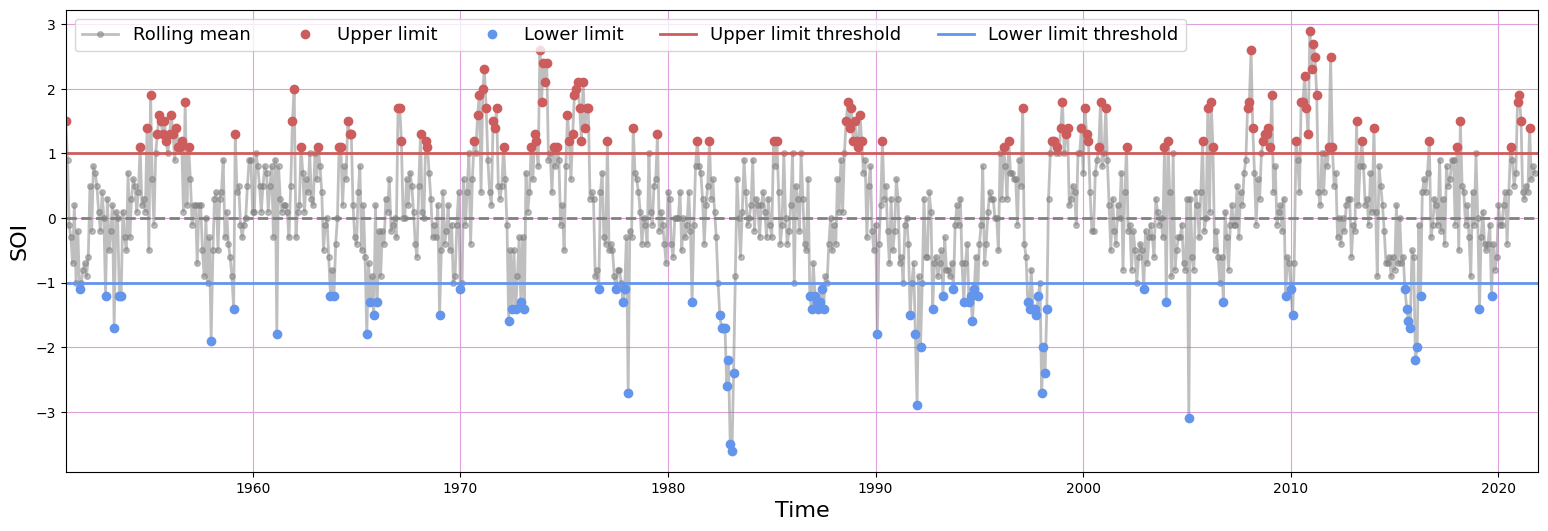

In [42]:
soi_p = np.loadtxt(op.join(p_index, "soi.txt"), skiprows=4, usecols=np.arange(0, 13))
soi = soi_format(soi_p, rolling_mean=1, rol_months=1)
thr1 = 1
thr2 = -1
soi = plot_index(soi, name="SOI", l1=thr1, l2=thr2, figsize=[19, 6])

In [43]:
soi = soi.dropna(dim="time")

In [44]:
u = np.intersect1d(pcs.time.values, soi.time.values)
pcs_soi = pcs.sel(time=u)
pcs_soi = pcs_soi.rename({"n_component": "n_pcs"})
pcs_soi["soi"] = (("time"), soi.sel(time=u).index.values)

In [45]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_soi = []
for i in pcs_soi.n_pcs.values:
    CORR_soi.append(
        (np.corrcoef(pcs_soi.PCs.isel(n_pcs=i).values, pcs_soi.soi.values)[0, 1])
    )
CORR_soi = np.array(CORR_soi)

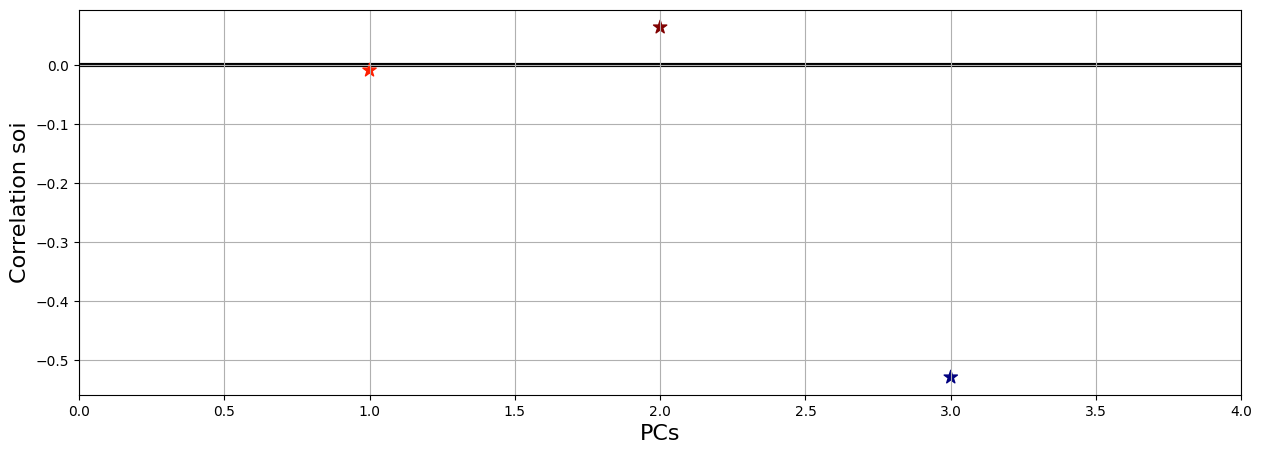

In [46]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_soi.n_pcs.values + 1,
    CORR_soi,
    s=100,
    c=CORR_soi,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_soi.n_pcs.values[0], pcs_soi.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_soi.n_pcs.values[0], pcs_soi.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation soi", fontsize=16)
ax.grid()

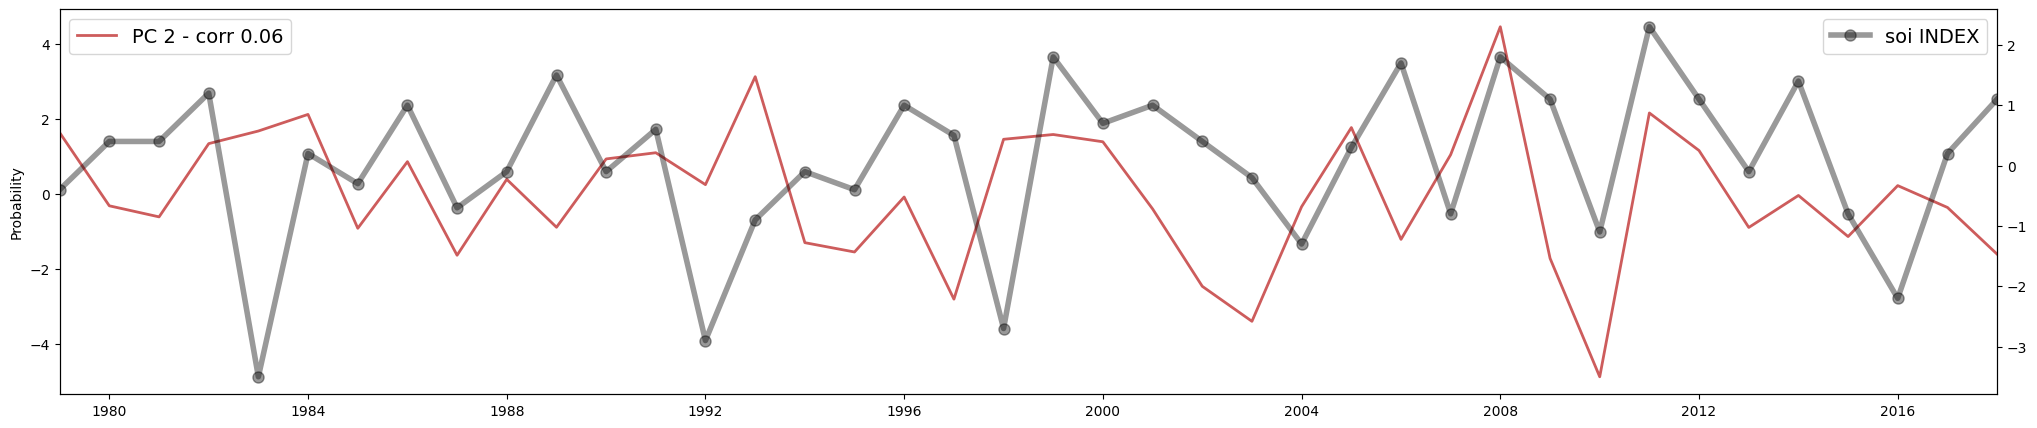

In [47]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_soi > 0.03)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_soi.time.values,
        pcs_soi.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_soi[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_soi.time.values[0], pcs_soi.time.values[-1])

ax.legend(fontsize=14, ncol=5, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_soi.time.values,
    pcs_soi.soi.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="soi INDEX",
)
ax1.legend(fontsize=14, loc=1)

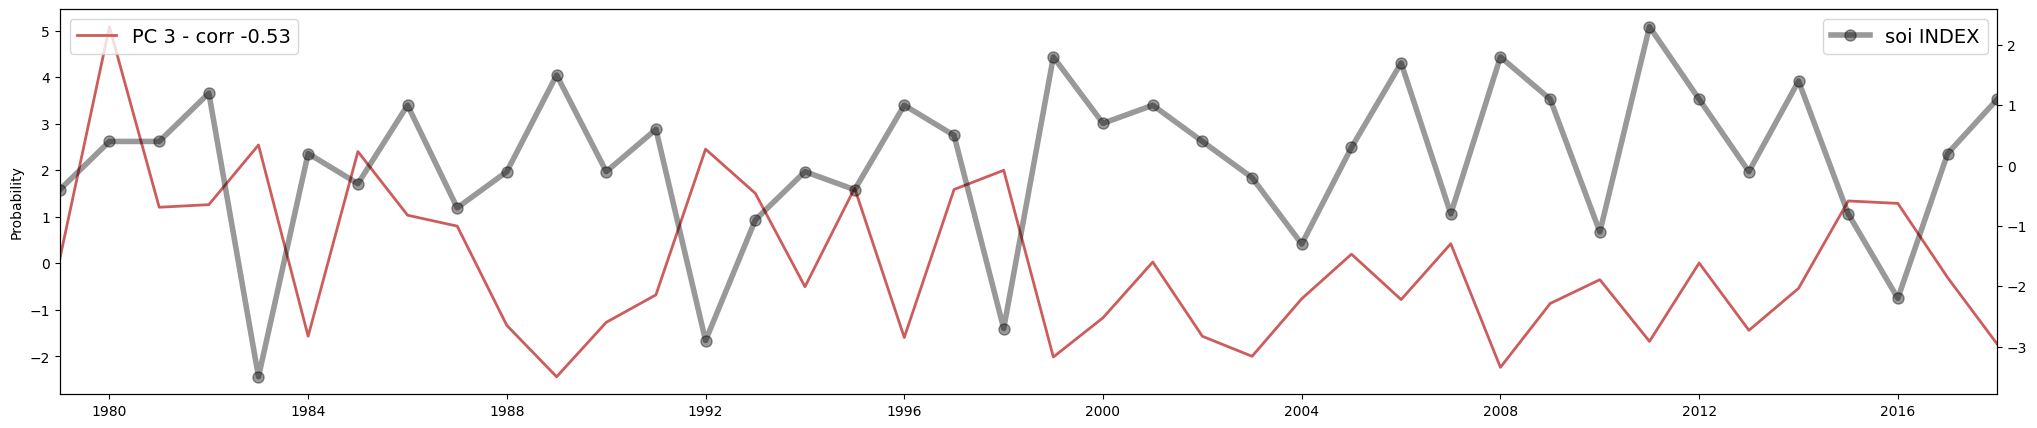

In [48]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_soi < -0.5)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_soi.time.values,
        pcs_soi.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_soi[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_soi.time.values[0], pcs_soi.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_soi.time.values,
    pcs_soi.soi.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="soi INDEX",
)
ax1.legend(fontsize=14, loc=1)

## SAM

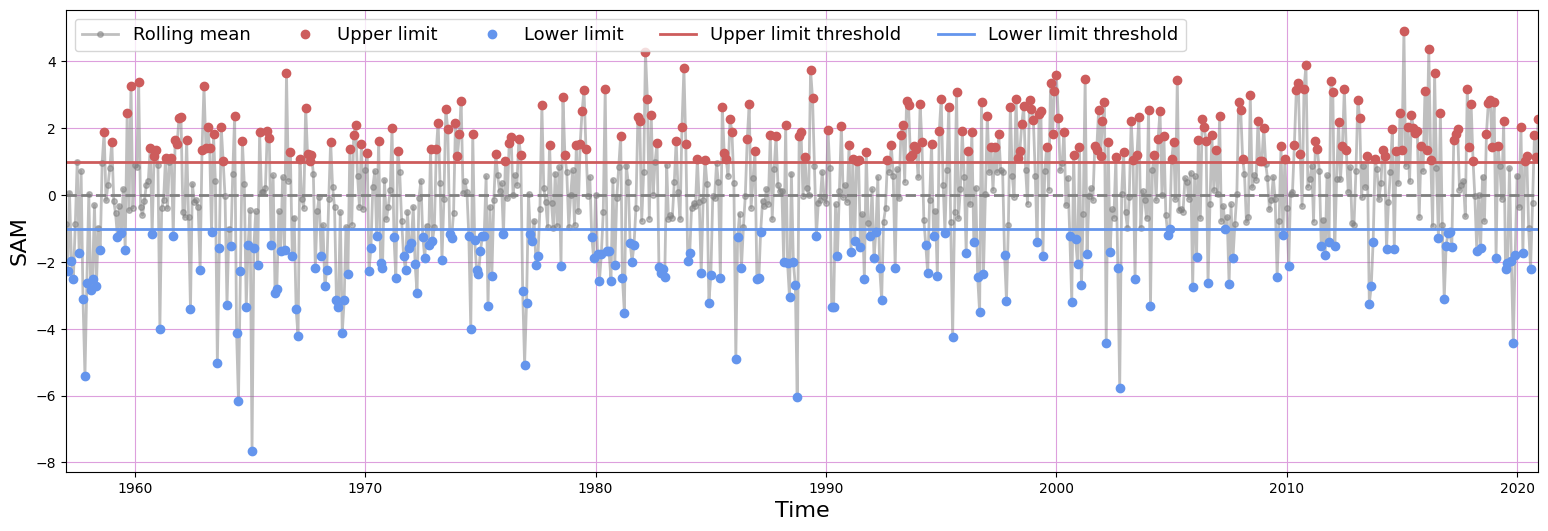

In [49]:
sam_p = np.loadtxt(op.join(p_index, "sam.txt"), skiprows=2, usecols=np.arange(0, 13))
sam = sam_format(sam_p, rolling_mean=1, rol_months=1)
thr1 = 1
thr2 = -1
sam = plot_index(sam, name="SAM", l1=thr1, l2=thr2, figsize=[19, 6])

In [50]:
sam = sam.dropna(dim="time")

In [51]:
u = np.intersect1d(pcs.time.values, sam.time.values)
pcs_sam = pcs.sel(time=u)
pcs_sam = pcs_sam.rename({"n_component": "n_pcs"})
pcs_sam["sam"] = (("time"), sam.sel(time=u).index.values)

In [52]:
# fig, ax = plt.subplots(1,1, figsize = [15, 5])
CORR_sam = []
for i in pcs_sam.n_pcs.values:
    CORR_sam.append(
        (np.corrcoef(pcs_sam.PCs.isel(n_pcs=i).values, pcs_sam.sam.values)[0, 1])
    )
CORR_sam = np.array(CORR_sam)

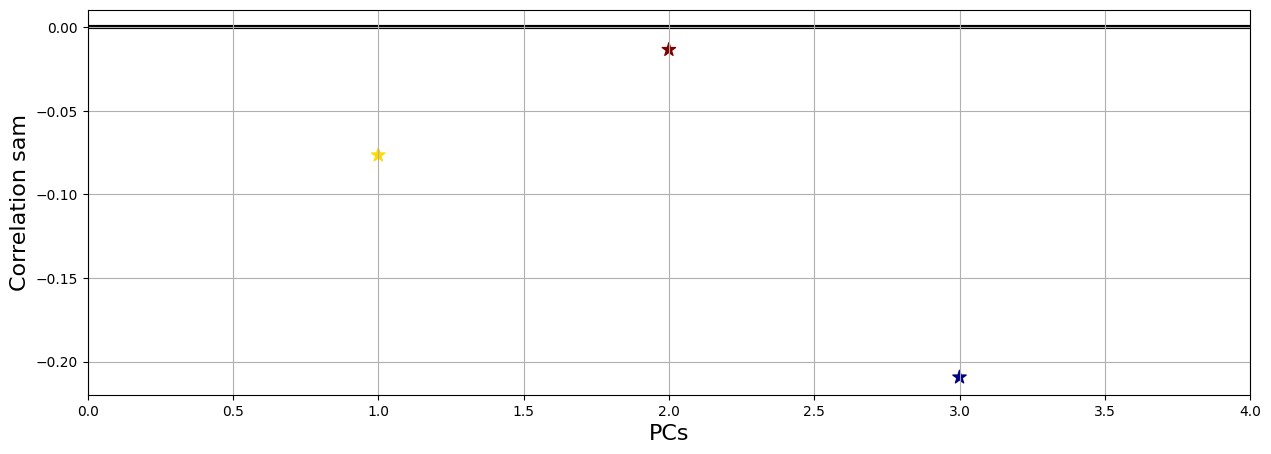

In [53]:
fig, ax = plt.subplots(1, 1, figsize=[15, 5])
ax.scatter(
    pcs_sam.n_pcs.values + 1,
    CORR_sam,
    s=100,
    c=CORR_sam,
    marker="*",
    cmap="jet",
    label="",
)
ax.plot(
    [pcs_sam.n_pcs.values[0], pcs_sam.n_pcs.values[-1]+2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_sam.n_pcs.values[0], pcs_sam.n_pcs.values[-1]+2)
# ax.legend()
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation sam", fontsize=16)
ax.grid()

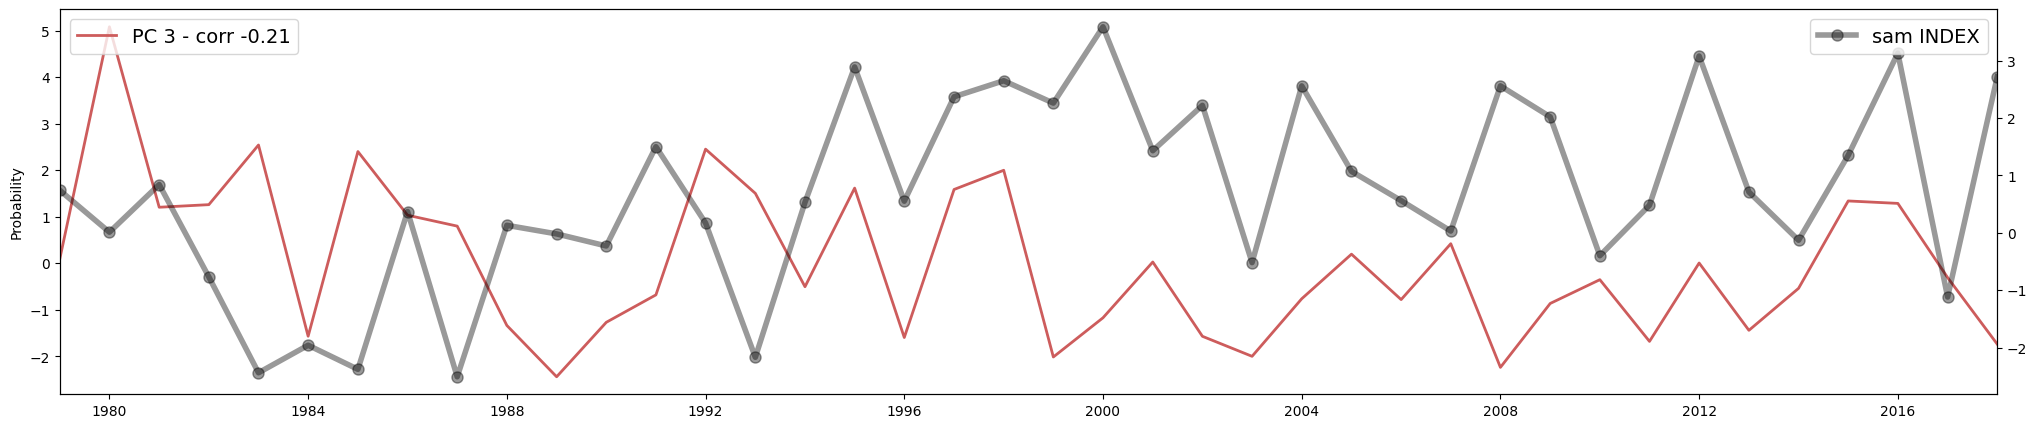

In [54]:
fig, ax = plt.subplots(1, 1, figsize=[25, 5])

pcs_sel_list = np.where(CORR_sam < -0.2)[0]

for ipc, pc_sel in enumerate(pcs_sel_list):
    ax.plot(
        pcs_sam.time.values,
        pcs_sam.PCs.isel(n_pcs=pc_sel).values,
        label="PC {0} - corr {1}".format(pc_sel + 1, np.round(CORR_sam[pc_sel], 2)),
        linewidth=2,
        color=list_colors[ipc],
    )
    ax.set_xlim(pcs_sam.time.values[0], pcs_sam.time.values[-1])

ax.legend(fontsize=14, ncol=3, loc=2)
ax.set_ylabel("Probability")


ax1 = ax.twinx()
ax1.plot(
    pcs_sam.time.values,
    pcs_sam.sam.values,
    ".-",
    color="black",
    markersize=16,
    linewidth=4,
    alpha=0.4,
    label="sam INDEX",
)
ax1.legend(fontsize=14, loc=1)

## Summary

In [55]:
vars_plot = [
    CORR_AO,
    CORR_AMO,
    CORR_SCA,
    CORR_olr,
    CORR_pdo,
    CORR_soi,
    CORR_sam,
]
color_index = [
    "royalblue",
    "purple",
    "coral",
    "crimson",
    "navy",
    "limegreen",
    "lightseagreen",
]
markers = ["o", "D", "X", "p", "*", "<", "v"]
name_var = ["AO", "AMO", "SCA", "OLR", "PDO", "SOI", "SAM"]

In [56]:
matrix_corr = np.vstack(vars_plot)
max_ind = np.argmax(np.abs(matrix_corr), axis=0)

max_pos = np.argmax(matrix_corr, axis=0)
max_neg = np.argmin(matrix_corr, axis=0)

# ALL PLOTS

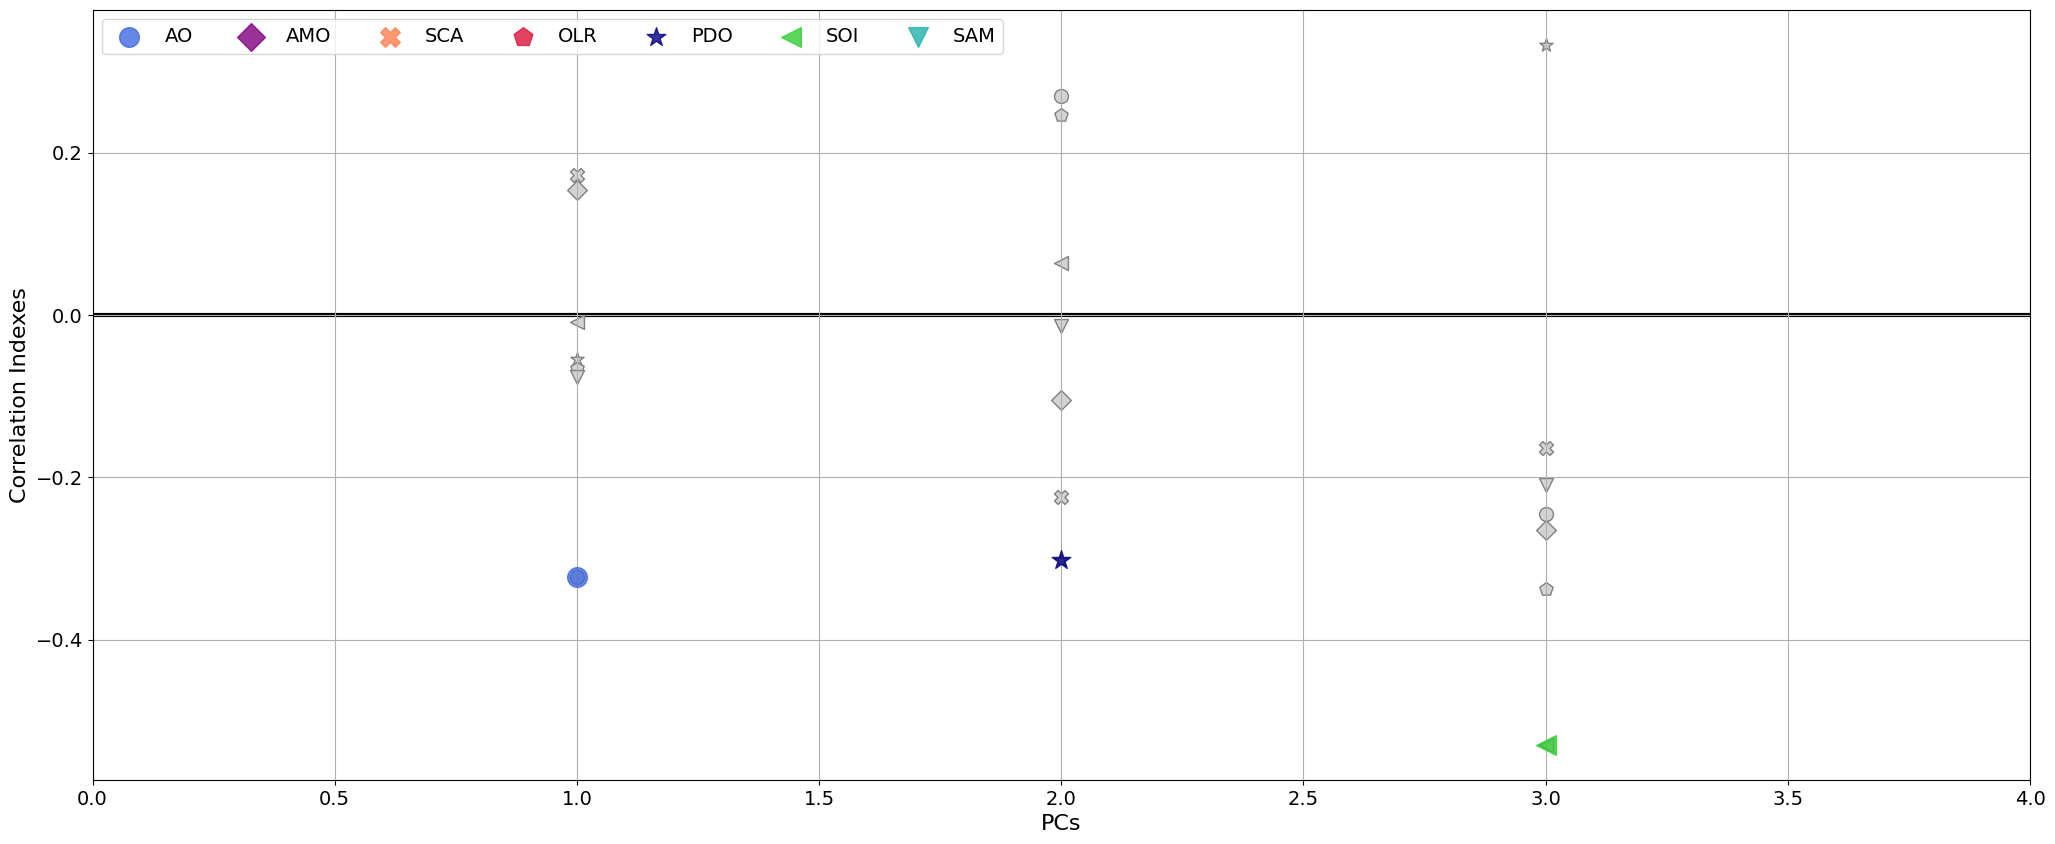

In [57]:
fig, ax = plt.subplots(1, 1, figsize=[25, 10])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=100,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_ind == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


---

## NIÑO 3.4

In [58]:
# Loas n34 index
n34 = np.loadtxt(op.join(p_index, "ninho34.txt"), skiprows=1, max_rows=74)
n34 = n34_format(n34, rolling_mean=1)
time_index = pd.to_datetime(n34["time"].values)
time_index = time_index.map(lambda t: t.replace(day=1))
n34["time"] = time_index

## NAO

In [59]:
# Load NAO Index
nao_p = np.loadtxt(op.join(p_index, "nao.txt"), skiprows=2, usecols=np.arange(0, 13))
nao = nao_format(nao_p, rolling_mean=0, rol_months=1)
nao

<xarray.Dataset> Size: 13kB
Dimensions:  (time: 828)
Coordinates:
  * time     (time) datetime64[s] 7kB 1952-01-01 1952-02-01 ... 2020-12-01
Data variables:
    index    (time) float64 7kB 0.93 -0.83 -1.49 1.01 ... 0.98 -0.65 2.54 -0.3

## PNA

In [60]:
pna_p = np.loadtxt(op.join(p_index, "pna.txt"), skiprows=2, usecols=np.arange(0, 13))
pna = pna_format(pna_p, rolling_mean=1, rol_months=1)
pna = pna.dropna(dim="time")

---

## Summary

In [ ]:
vars_plot = [
    CORR_NAO,
    CORR_AO,
    CORR_AMO,
    CORR_SCA,
    CORR_olr,
    CORR_n34,
    CORR_pdo,
    CORR_soi,
    CORR_pna,
    CORR_sam,
]
color_index = [
    "violet",
    "royalblue",
    "purple",
    "coral",
    "crimson",
    "darkgreen",
    "navy",
    "limegreen",
    "darkred",
    "lightseagreen",
]
markers = ["s", "o", "D", "X", "p", "^", "*", "<", "8", "v"]
name_var = ["NAO", "AO", "AMO", "SCA", "OLR", "N34", "PDO", "SOI", "PNA", "SAM"]

In [ ]:
matrix_corr = np.vstack(vars_plot)
max_ind = np.argmax(np.abs(matrix_corr), axis=0)

max_pos = np.argmax(matrix_corr, axis=0)
max_neg = np.argmin(matrix_corr, axis=0)

# ALL PLOTS

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[25, 10])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=100,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_ind == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


### Positive + Negative

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[25, 10])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=100,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_pos == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )

    imax = np.where(max_neg == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[20, 6])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=150,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_pos == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=300,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )

    imax = np.where(max_neg == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], 4)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


### Positive

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[25, 10])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=100,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_pos == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[20, 6])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=150,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_pos == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=300,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], 4)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


### Negative

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[25, 10])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=100,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_neg == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=200,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[20, 6])

for iv, v in enumerate(vars_plot):
    ax.scatter(
        pcs_olr.n_pcs.values + 1,
        v,
        s=150,
        c="lightgrey",
        marker=markers[iv],
        edgecolor="grey",
        cmap="jet",
    )  # , label = name_var[iv])

    imax = np.where(max_neg == iv)

    ax.scatter(
        pcs_olr.n_pcs.values[imax] + 1,
        v[imax],
        s=300,
        c=color_index[iv],
        alpha=0.8,
        edgecolor=color_index[iv],
        marker=markers[iv],
        label=name_var[iv],
        zorder=3,
    )


ax.plot(
    [pcs_olr.n_pcs.values[0], pcs_olr.n_pcs.values[-1] + 2],
    [0, 0],
    color="black",
    linewidth=3,
    zorder=-1,
)
ax.set_xlim(pcs_olr.n_pcs.values[0], 4)
ax.legend(ncol=len(name_var), fontsize=14)
ax.set_xlabel("PCs", fontsize=16)
ax.set_ylabel("Correlation Indexes", fontsize=16)
ax.grid()
plt.tick_params(axis="both", labelsize=14)
